[*********************100%***********************]  1 of 1 completed


Dataset of yfinance
Price         Adj Close        Close         High          Low         Open  \
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC        ^GSPC   
Date                                                                          
2024-09-27  5738.169922  5738.169922  5763.779785  5727.339844  5755.359863   
2024-09-30  5762.479980  5762.479980  5765.140137  5703.529785  5726.520020   
2024-10-01  5708.750000  5708.750000  5757.729980  5681.279785  5757.729980   
2024-10-02  5709.540039  5709.540039  5719.629883  5674.000000  5698.140137   
2024-10-03  5699.939941  5699.939941  5718.779785  5677.370117  5698.189941   

Price           Volume  
Ticker           ^GSPC  
Date                    
2024-09-27  3898530000  
2024-09-30  4425730000  
2024-10-01  4025180000  
2024-10-02  3829050000  
2024-10-03  3597450000  
MultiIndex([('Adj Close', '^GSPC'),
            (    'Close', '^GSPC'),
            (     'High', '^GSPC'),
            (      'Low', '^GSPC'),
   

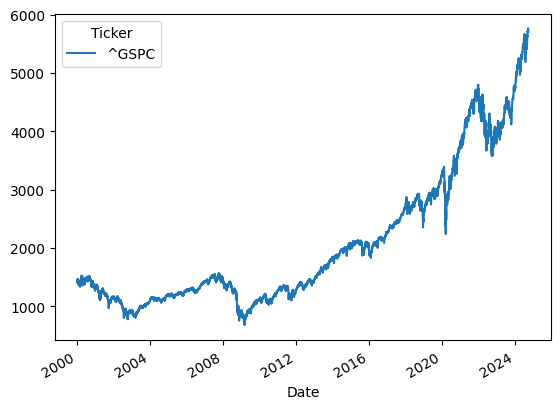

Scaled data
Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close'], dtype='object')
                Open      High       Low     Close    Volume  Adj Close
Date                                                                   
2024-09-27  0.998650  0.999292  1.000000  0.995220  0.319136   0.995220
2024-09-30  0.992976  0.999560  0.995295  1.000000  0.366631   1.000000
2024-10-01  0.999117  0.998099  0.990898  0.989436  0.330546   0.989436
2024-10-02  0.987393  0.990588  0.989460  0.989591  0.312877   0.989591
2024-10-03  0.987403  0.990420  0.990126  0.987703  0.292012   0.987703
TimeSeriesDataSet for Nbeats
       index      Open      High       Low     Close    Volume  Adj Close  \
0 2000-01-03  0.155416  0.154321  0.152468  0.153106  0.051867   0.153106   
1 2000-01-04  0.152656  0.149829  0.144380  0.142135  0.058822   0.142135   
2 2000-01-05  0.141678  0.141559  0.140477  0.142664  0.065713   0.142664   
3 2000-01-06  0.142207  0.141289  0.143326  0.142927  0.066326   0.1

C:\Users\Sai_Kiran\AppData\Local\Temp\ipykernel_21708\171212278.py:48: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  future_data = pd.DataFrame(index=future_dates, columns=scaled_data.columns).fillna(0)


Nbeats Model


Seed set to 42
C:\Users\Sai_Kiran\PycharmProjects\Artificial_Intelligence\.venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:208: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
C:\Users\Sai_Kiran\PycharmProjects\Artificial_Intelligence\.venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:208: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
C:\Users\Sai_Kiran\PycharmProjects\Artificial_Intelligence\.venv\Lib\site-packages\pytorch_forecasting\models\nbeats\__init__.py:107: UserWarning: In pytorch-forecasting models, on versions 1.1.X, the default optimizer defaults to 'adam', if pytorch_optimizer is not installed, otherwise it defaults to 'ranger' from pytorch_optimizer. From version 1.2.0, the

NameError: name 'exit' is not defined

In [1]:
#load the data
import yfinance as yf
ticker = "^GSPC"  # Replace with the desired ticker symbol
data_1 = yf.download(ticker, start="2000-01-01", end="2024-10-04")



#print the data
print("Dataset of yfinance")

print(data_1.tail())
print(data_1.columns)



#Graph of the above data
print("Graph of the data")

import matplotlib.pyplot as plt
data_1['Close'].plot()
plt.show()


#scale the data
print("Scaled data")

from sklearn.preprocessing import MinMaxScaler
import pandas as pd
scaler_1 = MinMaxScaler()       # can use MinMaxScaler too
# Fit the scaler to your data and transform it
scaled_input = scaler_1.fit_transform(data_1[['Open', 'High', 'Low', 'Close',  'Volume']])  
# scaling target variable differently
scaled_target=scaler_1.fit_transform(data_1[['Adj Close']])
# Convert NumPy arrays to DataFrames before concatenation
scaled_input_df = pd.DataFrame(scaled_input, columns=['Open', 'High', 'Low', 'Close', 'Volume'], index=data_1.index) # Convert scaled_input to DataFrame
scaled_target_df = pd.DataFrame(scaled_target, columns=['Adj Close'], index=data_1.index) # Convert scaled_target to DataFrame
scaled_data=pd.concat([scaled_input_df, scaled_target_df], axis=1)


print(scaled_data.columns)
print(scaled_data.tail())

#Build the Dataset for Training and Prediction
max_prediction_length=30
last_date = scaled_data.index.max()  # Assuming your DataFrame 'data' has a DatetimeIndex
future_dates = pd.date_range(last_date + pd.DateOffset(days=1), periods=max_prediction_length) 
#Create a DataFrame for future data:
future_data = pd.DataFrame(index=future_dates, columns=scaled_data.columns).fillna(0)
# Fill future_data with forward fill:
for column in future_data.columns:
    future_data[column] = scaled_data[column].iloc[-1]
# Fill with the last known values using forward fill
#future_data = pd.DataFrame(index=future_dates, columns=data.columns).fillna(method='ffill')
#Combine historical and future data:
scaled_data = pd.concat([scaled_data, future_data])



#Build the timeseriesdataset for training Nbeats
print("TimeSeriesDataSet for Nbeats")

scaled_data['group'] = 'dummy_group'
scaled_data['time_idx'] = range(len(scaled_data))
scaled_data.reset_index(inplace=True)

print(scaled_data.head())


from pytorch_forecasting.data import TimeSeriesDataSet, NaNLabelEncoder
scaled_data['time_idx'] = scaled_data['time_idx'].astype(int)  # Ensure it's integer

training_cutoff = scaled_data["time_idx"].max() - max_prediction_length


max_encoder_length = 365
context_length = max_encoder_length
prediction_length = max_prediction_length  # Ensure this is set as an integer
target_columns = "Adj Close"
time_varying_known_reals = ['Open', 'High', 'Low', 'Volume']
time_varying_unknown_reals = ['Adj Close']
training = TimeSeriesDataSet(
    scaled_data,  # Use the M4 DataFrame directly
    time_idx="time_idx",
    group_ids=["group"],
    target=target_columns,
    categorical_encoders={"group": NaNLabelEncoder().fit(scaled_data.group)},
    time_varying_unknown_reals=time_varying_unknown_reals,
    max_encoder_length=int(max_encoder_length),
    max_prediction_length=max_prediction_length,
    allow_missing_timesteps=True,
)
validation = TimeSeriesDataSet.from_dataset(training, scaled_data, min_prediction_idx=training_cutoff + 1)
batch_size = 64
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

print(train_dataloader)
print(val_dataloader)



#Build the N beat Model
print("Nbeats Model")

import lightning.pytorch as pl
from pytorch_lightning.callbacks import EarlyStopping
from pytorch_forecasting.models import NBeats

pl.seed_everything(42)
net = NBeats.from_dataset(
    training,
    learning_rate=.003,
    log_interval=10,
    log_val_interval=1,
    weight_decay=.001,
    widths=[64, 1024],
    backcast_loss_ratio=.16,
    num_blocks=[3,3,3],)

early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min")

trainer = pl.Trainer(
    max_epochs=25,
    accelerator="auto",
    enable_model_summary=True,
    gradient_clip_val=0.01,
    #callbacks=[early_stop_callback],
    limit_train_batches=150,
)

trainer.fit(
    net,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

In [ ]:
import torch

best_model_path = trainer.checkpoint_callback.best_model_path
best_model = NBeats.load_from_checkpoint(best_model_path)
actuals=torch.cat([y[0] for x, y in iter(val_dataloader)])
predictions=best_model.predict(val_dataloader, mode="raw", return_x=True)

best_model.plot_prediction(predictions.x, predictions.output, idx=0, add_loss_to_title=True)
plt.show()

In [ ]:
# Ensure torch is imported

# Predict using the model with raw mode to access additional outputs
predictions = best_model.predict(val_dataloader, mode="raw", return_x=True)

# Access the prediction components
prediction = predictions.output  # The full prediction output
trend = predictions.output.trend  # Trend component
backcast = predictions.output.backcast  # Backcast component
seasonality = predictions.output.seasonality  # Seasonality component

# Choose an index for visualization
idx = 0  # Adjust based on your desired data point

# Plot the interpretation for the chosen index
fig = best_model.plot_interpretation(
    x=predictions.x,
    output=predictions.output,
    idx=idx,
    plot_seasonality_and_generic_on_secondary_axis=True
)
plt.show()
